In [27]:
# Nếu chạy lần đầu trên Colab/local, mở comment dòng dưới để cài dependency.
# !pip install opencv-python ultralytics transformers torch pillow matplotlib

In [28]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from transformers import pipeline
from ultralytics import YOLO

In [29]:
# Load YOLO model và gender recognition model
# YOLO class 0 trong COCO là person.
def resolve_path(*candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    return Path(candidates[0])

yolo_model = YOLO("yolo26n.pt")

GENDER_MODEL_ID = 'rizvandwiki/gender-classification'
device = 0 if torch.cuda.is_available() else -1
gender_model = pipeline('image-classification', model=GENDER_MODEL_ID, device=device)

print(f'YOLO classes: {len(yolo_model.names)}')
print(f'Gender model: {GENDER_MODEL_ID}')

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 5477.49it/s]


YOLO classes: 80
Gender model: rizvandwiki/gender-classification


In [30]:
def detect_person_objects(image_bgr, model, conf=0.25):
    """Detect person objects and return a list of cropped person objects."""
    results = model.predict(image_bgr, classes=[0], conf=conf, verbose=False)
    person_objects = []
    detections = results[0]

    h, w = image_bgr.shape[:2]
    for idx, box in enumerate(detections.boxes):
        label =  detections.names[detections.boxes.cls[idx].item()]
        if label == 'person':
            box = detections.boxes.xyxy[idx].cpu().numpy().astype(int) # [x1, y1, x2, y2]
            confidence = detections.boxes.conf[idx].item()
            
            x1, y1, x2, y2 = map(int, box)
            crop_bgr = image_bgr[y1:y2, x1:x2].copy()
            if crop_bgr.size == 0:
                continue
            
            print(f"Detected person at index {idx} with confidence {confidence:.2f}")

            person_objects.append({
                'id': idx + 1,
                'bbox': (x1, y1, x2, y2),
                'confidence': float(box.conf.item()),
                'crop_bgr': crop_bgr,
            })

        
        # x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        # x1, y1 = max(0, x1), max(0, y1)
        # x2, y2 = min(w, x2), min(h, y2)

        
    return person_objects, results[0]


def predict_gender_for_objects(person_objects, classifier):
    """Run gender recognition on each person crop and append labels/scores."""
    for obj in person_objects:
        crop_rgb = cv2.cvtColor(obj['crop_bgr'], cv2.COLOR_BGR2RGB)
        pil_image = Image.fromarray(crop_rgb)
        predictions = classifier(pil_image)
        best = max(predictions, key=lambda item: item['score'])

        obj['gender_label'] = best['label']
        obj['gender_score'] = float(best['score'])
        obj['gender_predictions'] = predictions

    return person_objects


def build_person_matrices(person_objects, resize_to=(224, 224)):
    """Create crop collections as array/list and fixed-size tensor matrix."""
    person_crop_array = np.array([obj['crop_bgr'] for obj in person_objects], dtype=object)

    resized_crops = []
    for obj in person_objects:
        resized = cv2.resize(obj['crop_bgr'], resize_to)
        resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
        resized_crops.append(resized_rgb)

    resized_matrix = np.stack(resized_crops, axis=0) if resized_crops else np.empty((0, *resize_to, 3), dtype=np.uint8)
    return person_crop_array, resized_matrix


def draw_gender_labels(image_bgr, person_objects):
    annotated = image_bgr.copy()
    for obj in person_objects:
        x1, y1, x2, y2 = obj['bbox']
        label = f"{obj['gender_label']} {obj['gender_score']:.2f}"
        conf = f"person {obj['confidence']:.2f}"

        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 180, 255), 2)
        cv2.putText(annotated, label, (x1, max(20, y1 - 28)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 180, 255), 2)
        cv2.putText(annotated, conf, (x1, max(20, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2)
    return annotated


def show_bgr(image_bgr, title='', figsize=(12, 8)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [31]:
# Detect person, crop/slice từng object người thành array/matrix, nhận diện gender và label trên ảnh.
img_path = resolve_path('data/people.jpg', 'day-5/data/people.jpg')
image = cv2.imread(str(img_path))

if image is None:
    print(f'Image not found at {img_path}')
else:
    person_objects, yolo_result = detect_person_objects(image, yolo_model, conf=0.25)
    person_objects = predict_gender_for_objects(person_objects, gender_model)

    # Array object chứa crop gốc với kích thước khác nhau: shape = (N,)
    person_crop_array, person_resized_matrix = build_person_matrices(person_objects, resize_to=(224, 224))

    print(f'Number of persons detected: {len(person_objects)}')
    print(f'person_crop_array shape: {person_crop_array.shape}')
    print(f'person_resized_matrix shape: {person_resized_matrix.shape}  # (N, H, W, C)')

    for obj in person_objects:
        print(
            f"Person {obj['id']}: bbox={obj['bbox']}, "
            f"YOLO confidence={obj['confidence']:.3f}, "
            f"gender={obj['gender_label']} ({obj['gender_score']:.3f})"
        )

    annotated_image = draw_gender_labels(image, person_objects)
    show_bgr(annotated_image, 'YOLO Person Detection + Gender Recognition')

Detected person at index 0 with confidence 0.95


AttributeError: 'numpy.ndarray' object has no attribute 'conf'

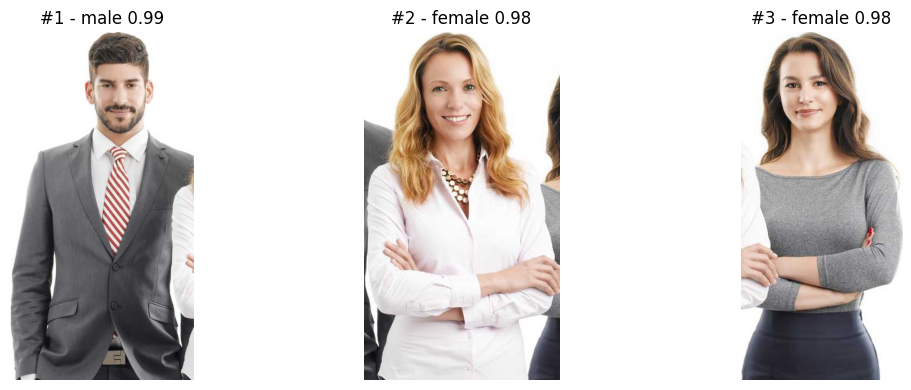

In [ ]:
# Hiển thị từng crop người đã được YOLO slice ra từ ảnh.
if 'person_objects' in globals() and person_objects:
    cols = min(4, len(person_objects))
    rows = int(np.ceil(len(person_objects) / cols))
    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, obj in enumerate(person_objects, start=1):
        crop_rgb = cv2.cvtColor(obj['crop_bgr'], cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, i)
        plt.imshow(crop_rgb)
        plt.title(f"#{obj['id']} - {obj['gender_label']} {obj['gender_score']:.2f}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('No person crops to display.')

Number of persons detected: 1
person_crop_array shape: (1, 1006, 1373, 3)
person_resized_matrix shape: (1, 224, 224, 3)  # (N, H, W, C)
Person 1: bbox=(np.int64(342), np.int64(68), np.int64(1715), np.int64(1074)), YOLO confidence=0.942, gender=male (0.981)


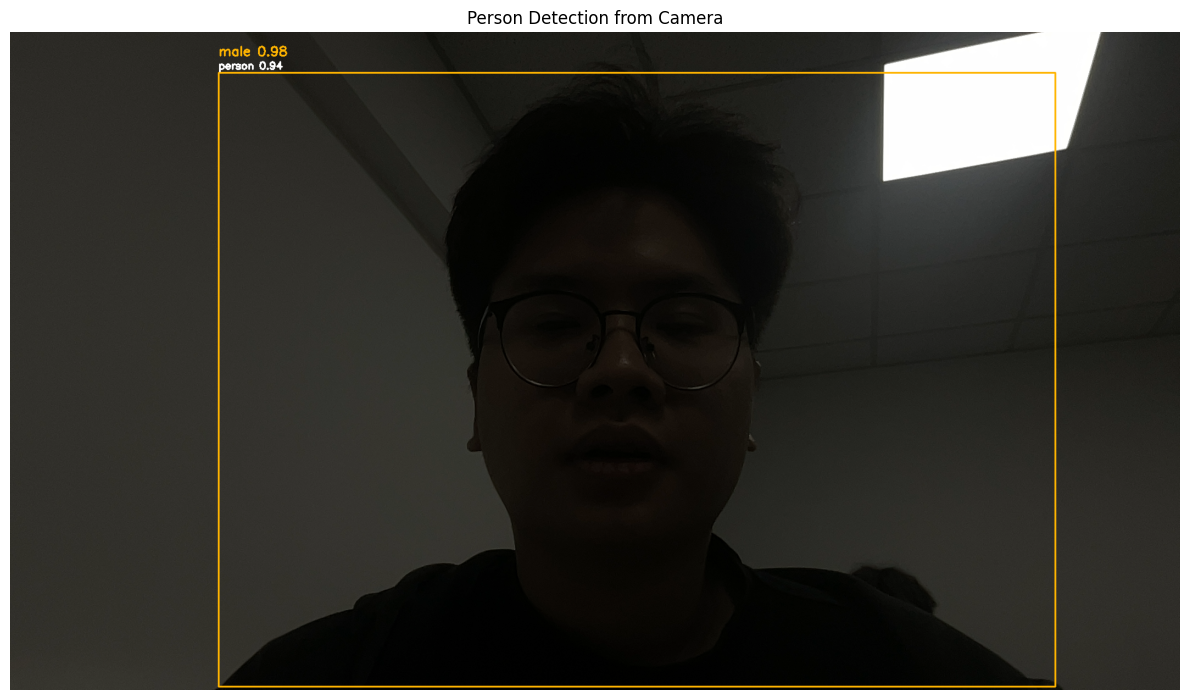

In [ ]:
cap = cv2.VideoCapture(0)

ret, frame = cap.read()
cap.release()

if ret:
    person_objects, _ = detect_person_objects(frame, yolo_model, conf=0.25)
    person_objects = predict_gender_for_objects(person_objects, gender_model)

    # Array object chứa crop gốc với kích thước khác nhau: shape = (N,)
    person_crop_array, person_resized_matrix = build_person_matrices(person_objects, resize_to=(224, 224))

    print(f'Number of persons detected: {len(person_objects)}')
    print(f'person_crop_array shape: {person_crop_array.shape}')
    print(f'person_resized_matrix shape: {person_resized_matrix.shape}  # (N, H, W, C)')

    for obj in person_objects:
        print(
            f"Person {obj['id']}: bbox={obj['bbox']}, "
            f"YOLO confidence={obj['confidence']:.3f}, "
            f"gender={obj['gender_label']} ({obj['gender_score']:.3f})"
        )

    annotated = draw_gender_labels(frame, person_objects)
    show_bgr(annotated, "Person Detection from Camera")
else:
    print("Cannot open camera")